In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

import os
os.environ['R_HOME'] = 'D:/Program Files/R-4.5.0' #@TODO include in some setup file

from simulation_engine.scenarios.iv.binary_iv import BinaryIV
from simulation_engine.scenarios.conf.binary_conf import BinaryConf
from simulation_engine.scenarios.iv.continuous_iv import ContinuousIV
from simulation_engine.util.plotting_util import PlottingUtil

import pandas as pd
pd.set_option('display.max_columns', None)

#disable warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import matplotlib.pyplot as plt
import seaborn as sns
import math
# from linearmodels.iv import IV2SLS
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.neural_network import MLPClassifier
# Train a decision tree classifier to predict 'tightest_bounds'
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from simulation_engine.util.plotting_util import PlottingUtil
pd.options.mode.chained_assignment = None  # default='warn'
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import numpy as np


In [77]:
#setup
results = pd.read_pickle('17_06/results.pkl')
results = pd.read_pickle('../BinEntropyConf/N2000/results_df.pkl')

import warnings
from pandas.errors import PerformanceWarning    # pandas ≥1.1

warnings.simplefilter("ignore", category=PerformanceWarning)

binaryConf = BinaryConf(results)
binaryConf.run(['ATE_entropybounds-underspecifyTheta'])

Running ATE_entropybounds-underspecifyTheta...


C:\Users\tmari\AppData\Roaming\Python\Python312\site-packages\cvxpy\problems\problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
C:\Users\tmari\AppData\Roaming\Python\Python312\site-packages\numpy\_core\fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\tmari\AppData\Roaming\Python\Python312\site-packages\numpy\_core\_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Error in LDL factorization when computing the nonzero elements. The problem seems to be non-convex.
factor_status: 0, num_vars: 8
Error in LDL initial factorization.
ERROR: init_lin_sys_work failure
Error in LDL factorization when computing the nonzero elements. The problem seems to be non-convex.
factor_status: 0, num_vars: 8
Error in LDL initial factorization.
ERROR: init_lin_sys_work failure
Error in LDL factorization when computing the nonzero elements. The problem seems to be non-convex.
factor_status: 0, num_vars: 8
Error in LDL initial factorization.
ERROR: init_lin_sys_work failure
Error in LDL factorization when computing the nonzero elements. The problem seems to be non-convex.
factor_status: 0, num_vars: 8
Error in LDL initial factorization.
ERROR: init_lin_sys_work failure
Error in LDL factorization when computing the nonzero elements. The problem seems to be non-convex.
factor_status: 0, num_vars: 8
Error in LDL initial factorization.
ERROR: init_lin_sys_work failure
Error

{'runtimes': {'ATE_entropybounds-underspecifyTheta': 247.68000197410583},
 'algorithms': ['ATE_entropybounds-underspecifyTheta'],
 'timestamp': '2025-07-24T10:26:20.822983'}

In [82]:
binaryConf.run(['PNS_entropybounds-underspecifyTheta'])

Running PNS_entropybounds-underspecifyTheta...


C:\Users\tmari\AppData\Roaming\Python\Python312\site-packages\cvxpy\problems\problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


PNS_entropybounds-underspecifyTheta completed in 194.59 seconds.
Total runtime: 194.61 seconds.


{'runtimes': {'PNS_entropybounds-underspecifyTheta': 194.59098982810974},
 'algorithms': ['PNS_entropybounds-underspecifyTheta'],
 'timestamp': '2025-07-24T10:53:05.817324'}

In [89]:
results = binaryConf.data
results.head(1)

,seed,intercept_X,intercept_Y,b_U_X,b_X_Y,b_U_Y,ATE_true,PNS_true,p_Y1_mean,p_Y0_mean,p_U,U,X,Y,epsilon_X,epsilon_Y,noise,entropy_U,entropy_X,entropy_Y,squasher_X_name,squasher_Y_name,heteroskedasticity_structure,ATE_OLS-0.99_bound_lower,ATE_OLS-0.99_bound_upper,ATE_OLS-0.99_bound_valid,ATE_OLS-0.99_bound_width,ATE_OLS-0.99_bound_failed,ATE_OLS-0.98_bound_lower,ATE_OLS-0.98_bound_upper,ATE_OLS-0.98_bound_valid,ATE_OLS-0.98_bound_width,ATE_OLS-0.98_bound_failed,ATE_OLS-0.95_bound_lower,ATE_OLS-0.95_bound_upper,ATE_OLS-0.95_bound_valid,ATE_OLS-0.95_bound_width,ATE_OLS-0.95_bound_failed,ATE_causaloptim_bound_lower,ATE_causaloptim_bound_upper,ATE_causaloptim_bound_valid,ATE_causaloptim_bound_width,ATE_causaloptim_bound_failed,PNS_causaloptim_bound_lower,PNS_causaloptim_bound_upper,PNS_causaloptim_bound_valid,PNS_causaloptim_bound_width,PNS_causaloptim_bound_failed,ATE_autobound_bound_lower,ATE_autobound_bound_upper,ATE_autobound_bound_valid,ATE_autobound_bound_width,ATE_autobound_bound_failed,PNS_autobound_bound_lower,PNS_autobound_bound_upper,PNS_autobound_bound_valid,PNS_autobound_bound_width,PNS_autobound_bound_failed,ATE_entropybounds-0.80_bound_lower,ATE_entropybounds-0.80_bound_upper,ATE_entropybounds-0.80_bound_valid,ATE_entropybounds-0.80_bound_width,ATE_entropybounds-0.80_bound_failed,ATE_entropybounds-0.80_theta,ATE_entropybounds-0.20_bound_lower,ATE_entropybounds-0.20_bound_upper,ATE_entropybounds-0.20_bound_valid,ATE_entropybounds-0.20_bound_width,ATE_entropybounds-0.20_bound_failed,ATE_entropybounds-0.20_theta,ATE_entropybounds-0.10_bound_lower,ATE_entropybounds-0.10_bound_upper,ATE_entropybounds-0.10_bound_valid,ATE_entropybounds-0.10_bound_width,ATE_entropybounds-0.10_bound_failed,ATE_entropybounds-0.10_theta,PNS_entropybounds-0.80_bound_lower,PNS_entropybounds-0.80_bound_upper,PNS_entropybounds-0.80_bound_valid,PNS_entropybounds-0.80_bound_width,PNS_entropybounds-0.80_bound_failed,PNS_entropybounds-0.80_theta,PNS_entropybounds-0.20_bound_lower,PNS_entropybounds-0.20_bound_upper,PNS_entropybounds-0.20_bound_valid,PNS_entropybounds-0.20_bound_width,PNS_entropybounds-0.20_bound_failed,PNS_entropybounds-0.20_theta,PNS_entropybounds-0.10_bound_lower,PNS_entropybounds-0.10_bound_upper,PNS_entropybounds-0.10_bound_valid,PNS_entropybounds-0.10_bound_width,PNS_entropybounds-0.10_bound_failed,PNS_entropybounds-0.10_theta,PNS_entropybounds-trueTheta_bound_lower,PNS_entropybounds-trueTheta_bound_upper,PNS_entropybounds-trueTheta_bound_valid,PNS_entropybounds-trueTheta_bound_width,PNS_entropybounds-trueTheta_bound_failed,PNS_entropybounds-trueTheta_theta,ATE_entropybounds-trueTheta_bound_lower,ATE_entropybounds-trueTheta_bound_upper,ATE_entropybounds-trueTheta_bound_valid,ATE_entropybounds-trueTheta_bound_width,ATE_entropybounds-trueTheta_bound_failed,ATE_entropybounds-trueTheta_theta,PNS_entropybounds-randomTheta_bound_lower,PNS_entropybounds-randomTheta_bound_upper,PNS_entropybounds-randomTheta_bound_valid,PNS_entropybounds-randomTheta_bound_width,PNS_entropybounds-randomTheta_bound_failed,PNS_entropybounds-randomTheta_theta,ATE_entropybounds-randomTheta_bound_lower,ATE_entropybounds-randomTheta_bound_upper,ATE_entropybounds-randomTheta_bound_valid,ATE_entropybounds-randomTheta_bound_width,ATE_entropybounds-randomTheta_bound_failed,ATE_entropybounds-randomTheta_theta,ATE_zaffalonbounds_bound_lower,ATE_zaffalonbounds_bound_upper,ATE_zaffalonbounds_bound_valid,ATE_zaffalonbounds_bound_width,ATE_zaffalonbounds_bound_failed,PNS_zaffalonbounds_bound_lower,PNS_zaffalonbounds_bound_upper,PNS_zaffalonbounds_bound_valid,PNS_zaffalonbounds_bound_width,PNS_zaffalonbounds_bound_failed,ATE_tianpearl_bound_lower,ATE_tianpearl_bound_upper,ATE_tianpearl_bound_width,ATE_tianpearl_bound_failed,ATE_tianpearl_bound_valid,PNS_tianpearl_bound_lower,PNS_tianpearl_bound_upper,PNS_tianpearl_bound_width,PNS_tianpearl_bound_failed,PNS_tianpearl_bound_valid,ATE_manski_bound_lower,ATE_manski_bound_upper,ATE_manski_bound_width,ATE_manski_bound_failed,ATE_

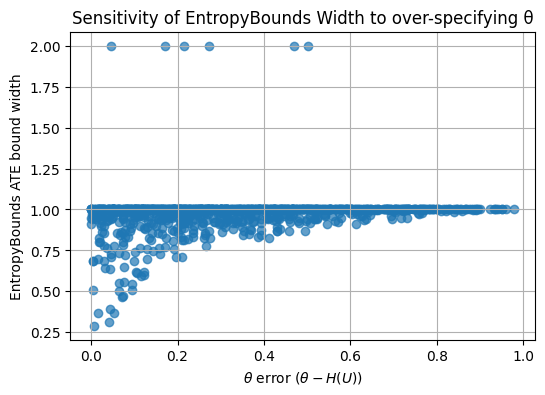

                            OLS Regression Results                            
Dep. Variable:             boundwidth   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.038
Method:                 Least Squares   F-statistic:                     47.37
Date:                Thu, 24 Jul 2025   Prob (F-statistic):           1.04e-11
Time:                        10:08:29   Log-Likelihood:                 736.66
No. Observations:                1002   AIC:                            -1469.
Df Residuals:                    1000   BIC:                            -1460.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.9366      0.008    121.448      0.0

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

query = "ATE"

# --- 1. Keep only draws with θ > H(U) and work on a copy to avoid the
#        dreaded SettingWithCopyWarning ---------------------------------
theta_too_high = (
    results[results[f"{query}_entropybounds-randomTheta_theta"] > results["entropy_U"]]
    .copy()
)

# --- 2. Mis-specification term ------------------------------------------------
theta_too_high["thetaerror"] = (
    theta_too_high[f"{query}_entropybounds-randomTheta_theta"]
    - theta_too_high["entropy_U"]
)

# --- 3. Analysis frame --------------------------------------------------------
df = pd.DataFrame(
    {
        "thetaerror": theta_too_high["thetaerror"],
        "boundwidth": theta_too_high[f"{query}_entropybounds-randomTheta_bound_width"],
        "tianpearl_boundwidth": theta_too_high[f"{query}_tianpearl_bound_width"],
    }
)

# --- 4. Quick visual check ----------------------------------------------------
plt.figure(figsize=(6, 4))
plt.scatter(df["thetaerror"], df["boundwidth"], alpha=0.7)
plt.xlabel(r"$\theta$ error ($\theta - H(U)$)")
plt.ylabel(f"EntropyBounds {query} bound width")
plt.title("Sensitivity of EntropyBounds Width to over-specifying θ")
plt.grid(True)
plt.show()

# --- 5. Regression with robust (HC3) SEs -------------------------------------
model = smf.ols(
    "boundwidth ~ thetaerror ",
    data=df,
).fit(cov_type="HC3")

print(model.summary())


In [72]:
df['entropy_U'].describe()

count    998.000000
mean       0.671742
std        0.230930
min        0.037622
25%        0.511865
50%        0.717910
75%        0.860844
max        0.982373
Name: entropy_U, dtype: float64

Optimization terminated successfully.
         Current function value: 0.526892
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                invalid   No. Observations:                 1992
Model:                          Logit   Df Residuals:                     1989
Method:                           MLE   Df Model:                            2
Date:                Thu, 24 Jul 2025   Pseudo R-squ.:                  0.1165
Time:                        11:40:54   Log-Likelihood:                -1049.6
converged:                       True   LL-Null:                       -1187.9
Covariance Type:            nonrobust   LLR p-value:                 8.084e-61
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1883      0.098      1.923      0.054      -0.004       0.380
thetaerror     4.1870      0.

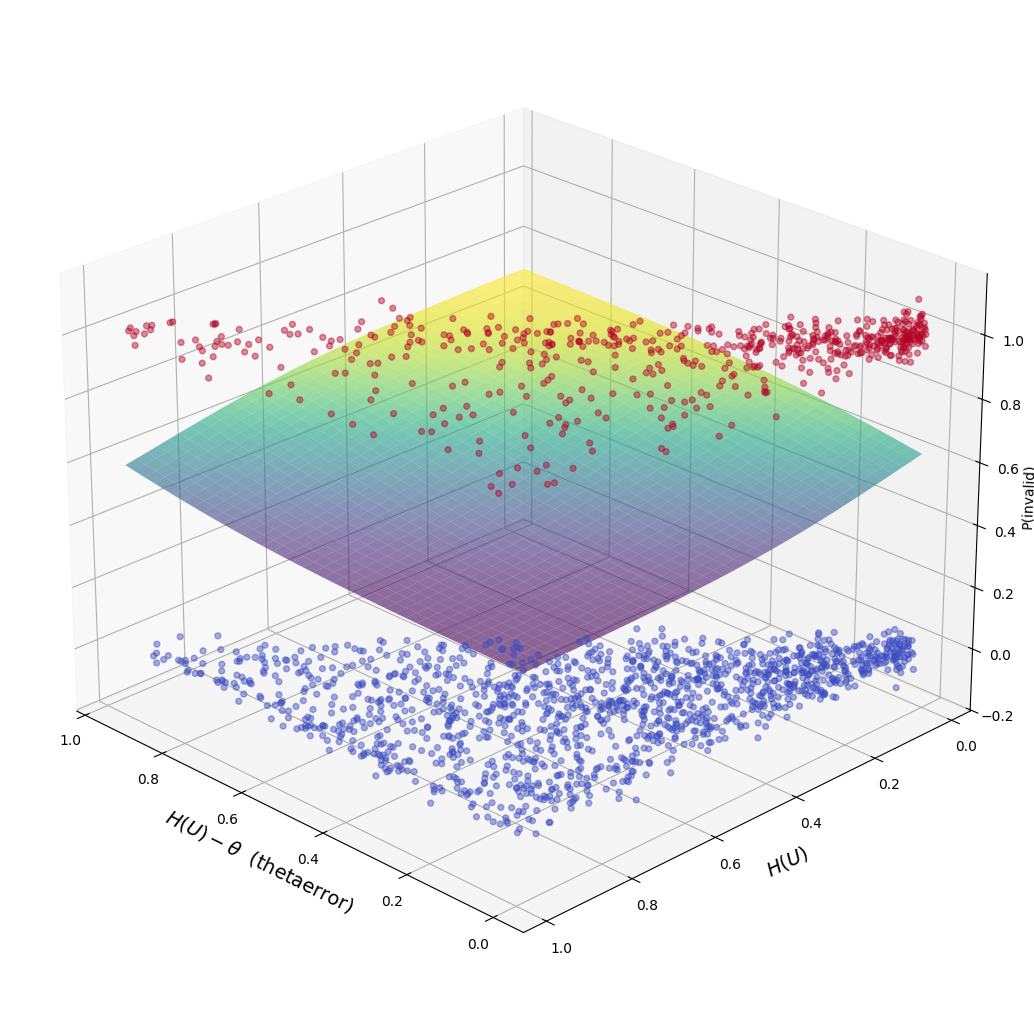

In [144]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D          # noqa: F401 (needed for 3-D)
from matplotlib import cm
import statsmodels.formula.api as smf
from scipy.special import expit

query = "ATE"

# ---------------------------------------------------------------------------
# 1.  θ under-specified subset
# ---------------------------------------------------------------------------
theta_too_low = results[
    results[f"{query}_entropybounds-underspecifyTheta_theta"] < results["entropy_U"]
].copy()

theta_too_low["thetaerror"] = (
    theta_too_low["entropy_U"]
    - theta_too_low[f"{query}_entropybounds-underspecifyTheta_theta"]
)
theta_too_low["invalid"] = (
    ~theta_too_low[f"{query}_entropybounds-underspecifyTheta_bound_valid"]
).astype(int)

df = theta_too_low[["thetaerror", "entropy_U", "invalid"]].dropna()

# ---------------------------------------------------------------------------
# 2.  Logistic regression with interaction
# ---------------------------------------------------------------------------
# Ensure 'invalid' is strictly 0 or 1 for regression
df["invalid"] = (df["invalid"] > 0).astype(int)
logit_mod = smf.logit("invalid ~ thetaerror + entropy_U", data=df).fit(disp=True)
print(logit_mod.summary())

# ---------------------------------------------------------------------------
# 3.  3-D scatter + fitted probability surface
# ---------------------------------------------------------------------------
fig = plt.figure(figsize=(25, 25))
ax = fig.add_subplot(111, projection="3d")

# ---- raw points (jitter z a bit so 0/1 dots separate visually) -------------
z_jitter = df["invalid"] + 0.03 * np.random.randn(len(df))
ax.scatter(
    df["thetaerror"],
    df["entropy_U"],
    z_jitter,
    c=df["invalid"],
    cmap="coolwarm",
    alpha=0.45,
    s=18,
    label="simulations",
)

# ---- fitted surface --------------------------------------------------------
theta_grid = np.linspace(df.thetaerror.min(), df.thetaerror.max(), 40)
entropy_grid = np.linspace(df.entropy_U.min(), df.entropy_U.max(), 40)
Theta, Entropy = np.meshgrid(theta_grid, entropy_grid)

grid_df = pd.DataFrame(
    {
        "thetaerror": Theta.ravel(),
        "entropy_U": Entropy.ravel(),
    }
)
# patsy created the interaction term automatically in the model,
# but to predict we must supply it explicitly:
grid_df["thetaerror:entropy_U"] = grid_df["thetaerror"] * grid_df["entropy_U"]

Z = expit(logit_mod.predict(grid_df)).values.reshape(Theta.shape)

ax.plot_surface(
    Theta,
    Entropy,
    Z,
    cmap=cm.viridis,
    alpha=0.6,
    rstride=1,
    cstride=1,
    edgecolor="none",
    label="fitted surface",
)




# ---- cosmetics -------------------------------------------------------------
ax.set_xlabel(r"$H(U)-\theta$  (thetaerror)", fontsize=14)
ax.set_ylabel(r"$H(U)$", fontsize=14)
ax.set_zlabel("P(invalid)", labelpad=-0.5, fontsize=10)
# ax.set_title("EntropyBounds validity as a joint function of $H(U)$ and θ-error")
ax.view_init(elev=25, azim=135)       # nice angle; tweak to taste
fig.subplots_adjust(left=0.0, right=0.4)  # or 0.8 if needed
ax.zaxis.label.set_rotation(90)


plt.show()

